# Causal Impact of Email Marketing Campaigns
### A Randomized Controlled Trial Analysis — Hillstrom (2008) Dataset

**What this project covers:**
- Estimating the causal effect of two email campaigns (Mens, Womens) versus no email on customer spend, using a clean three-arm RCT
- Full validity checks: sample ratio mismatch, covariate balance, identification assumptions
- CUPED variance reduction — including an honest, diagnosed **null result**, since the technique only helps when a pre-period covariate correlates well with the outcome, which is not the case here
- Robustness checks via a distribution-free test and outlier sensitivity
- Exploratory heterogeneous treatment effects (CATE) via an X-learner

**Workflow followed:** Estimand framing → Data sanity → Assignment integrity (SRM) → Covariate balance → Outcome exploration → Identification assumptions → Estimator selection & CUPED → Robustness checks → Final estimates → Heterogeneous effects


## Dataset Overview

The dataset originates from a randomized email marketing experiment for a retail brand where Customers were split into three groups:
* Observations ~ 64,000 customers
* one received a men’s merchandise email (1/3 of dataset)
* one received a women’s merchandise email (1/3 of dataset)
* control received no emails (1/3 of dataset)

It also includes customer level variables such as purchase history, gender, recent spending, and segment assignment. Outcome variables capture whether a purchase occurred and its dollar value after the email campaign.

variables description : 
* Recency: Months since last purchase.
* History_Segment: Categorization of dollars spent in the past year.
* History: Actual dollar value spent in the past year.
* Mens: 1/0 indicator, 1 = customer purchased Mens merchandise in the past year.
* Womens: 1/0 indicator, 1 = customer purchased Womens merchandise in the past year.
* Zip_Code: [Urban, Suburban, Rural]
* Newbie: 1/0 indicator, 1 = New customer in the past twelve months.
* Channel: Describes the channels the customer purchased from in the past year.
* Segment : [Mens E-Mail, Womens E-Mail, No E-Mail]
* Visit: 1/0 indicator, 1 = Customer visited website in the following two weeks.
* Conversion: 1/0 indicator, 1 = Customer purchased merchandise in the following two weeks.
* Spend: Actual dollars spent in the following two weeks.

Kevin Hillstrom released the dataset to illustrate how data driven testing can improve marketing decisions beyond intuition on his blog : [minethatdata](https://blog.minethatdata.com/)

## Step 0 — Framing the Estimand

for this analysis I will estimate the treatment effect for men receiving promotional emails ('Segment' = 'Mens Email')  vs not receiving promotional emails ('Segment' = 'No Email') on the spending ('spend') same goes for women using CUPED with the historical data to remove pre treatment noise and have less variance and more consistent estimates ('History') other secondary treatment effects are conversion and visit ('Conversion','Visit')
Worth to note that the control group wont include the opposite gender treatment but only No email as it may cause unwanted effect manifesting from having opposite gender email in the control group.
Also since using the same control group for both treatment effects further cleaning is needed if we want to compare them both usign the same control group.

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\bahak\Project 6 - End-to-End Experimentation Platform\data\Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv')

## Step 1 — Data & Pipeline Sanity

In [2]:
print(f"shape = {df.shape}")
print("-"*60)
print(df.info())
print("-"*60)
print(f"duplicated rows : {df.duplicated().sum()} => {df.duplicated().sum()/df.shape[0] * 100}% ")
print(df[df.duplicated(keep=False)].groupby('segment').size())

shape = (64000, 12)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB
None
------------------------------------------------------------
duplicated rows : 6562 => 10.253125% 


In [3]:
print(df.describe())
print("-"*100)
print(f"values for mens = {df['mens'].unique()}")
print(f"values for womens = {df['womens'].unique()}")
print(f"values for newbie = {df['newbie'].unique()}")
print(f"values for visit = {df['visit'].unique()}")
print(f"values for conversion = {df['conversion'].unique()}")
print("-"*100)
print(f"values for history_segment = {df['history_segment'].unique()}")
print(f"values for channel = {df['channel'].unique()}")
print(f"values for segment = {df['segment'].unique()}")

            recency       history          mens        womens        newbie  \
count  64000.000000  64000.000000  64000.000000  64000.000000  64000.000000   
mean       5.763734    242.085656      0.551031      0.549719      0.502250   
std        3.507592    256.158608      0.497393      0.497526      0.499999   
min        1.000000     29.990000      0.000000      0.000000      0.000000   
25%        2.000000     64.660000      0.000000      0.000000      0.000000   
50%        6.000000    158.110000      1.000000      1.000000      1.000000   
75%        9.000000    325.657500      1.000000      1.000000      1.000000   
max       12.000000   3345.930000      1.000000      1.000000      1.000000   

              visit    conversion         spend  
count  64000.000000  64000.000000  64000.000000  
mean       0.146781      0.009031      1.050908  
std        0.353890      0.094604     15.036448  
min        0.000000      0.000000      0.000000  
25%        0.000000      0.000000     

## Step 2 — Assignment Integrity Check (SRM)

In [4]:
from scipy.stats import chisquare

observed = df['segment'].value_counts()
expected = [len(df)/3]*3
chisquare(observed, expected)

Power_divergenceResult(statistic=0.20253125000000002, pvalue=0.9036929575604196)

## Step 3 — Pre-Treatment Comparability (Covariate Balance)

                            variable       SMD
0                            recency  0.006832
1       history_segment_1) $0 - $100  0.010917
2     history_segment_2) $100 - $200 -0.016360
3     history_segment_3) $200 - $350  0.005471
4     history_segment_4) $350 - $500 -0.004258
5     history_segment_5) $500 - $750 -0.009740
6   history_segment_6) $750 - $1,000  0.006073
7        history_segment_7) $1,000 +  0.015835
8                            history  0.007613
9                               mens -0.004582
10                            womens  0.007589
11                    zip_code_Rural  0.013659
12                zip_code_Surburban -0.011744
13                    zip_code_Urban  0.001972
14                            newbie -0.000892
15              channel_Multichannel -0.004182
16                     channel_Phone -0.008276
17                       channel_Web  0.011014
                            variable       SMD
0                            recency  0.005180
1       histo

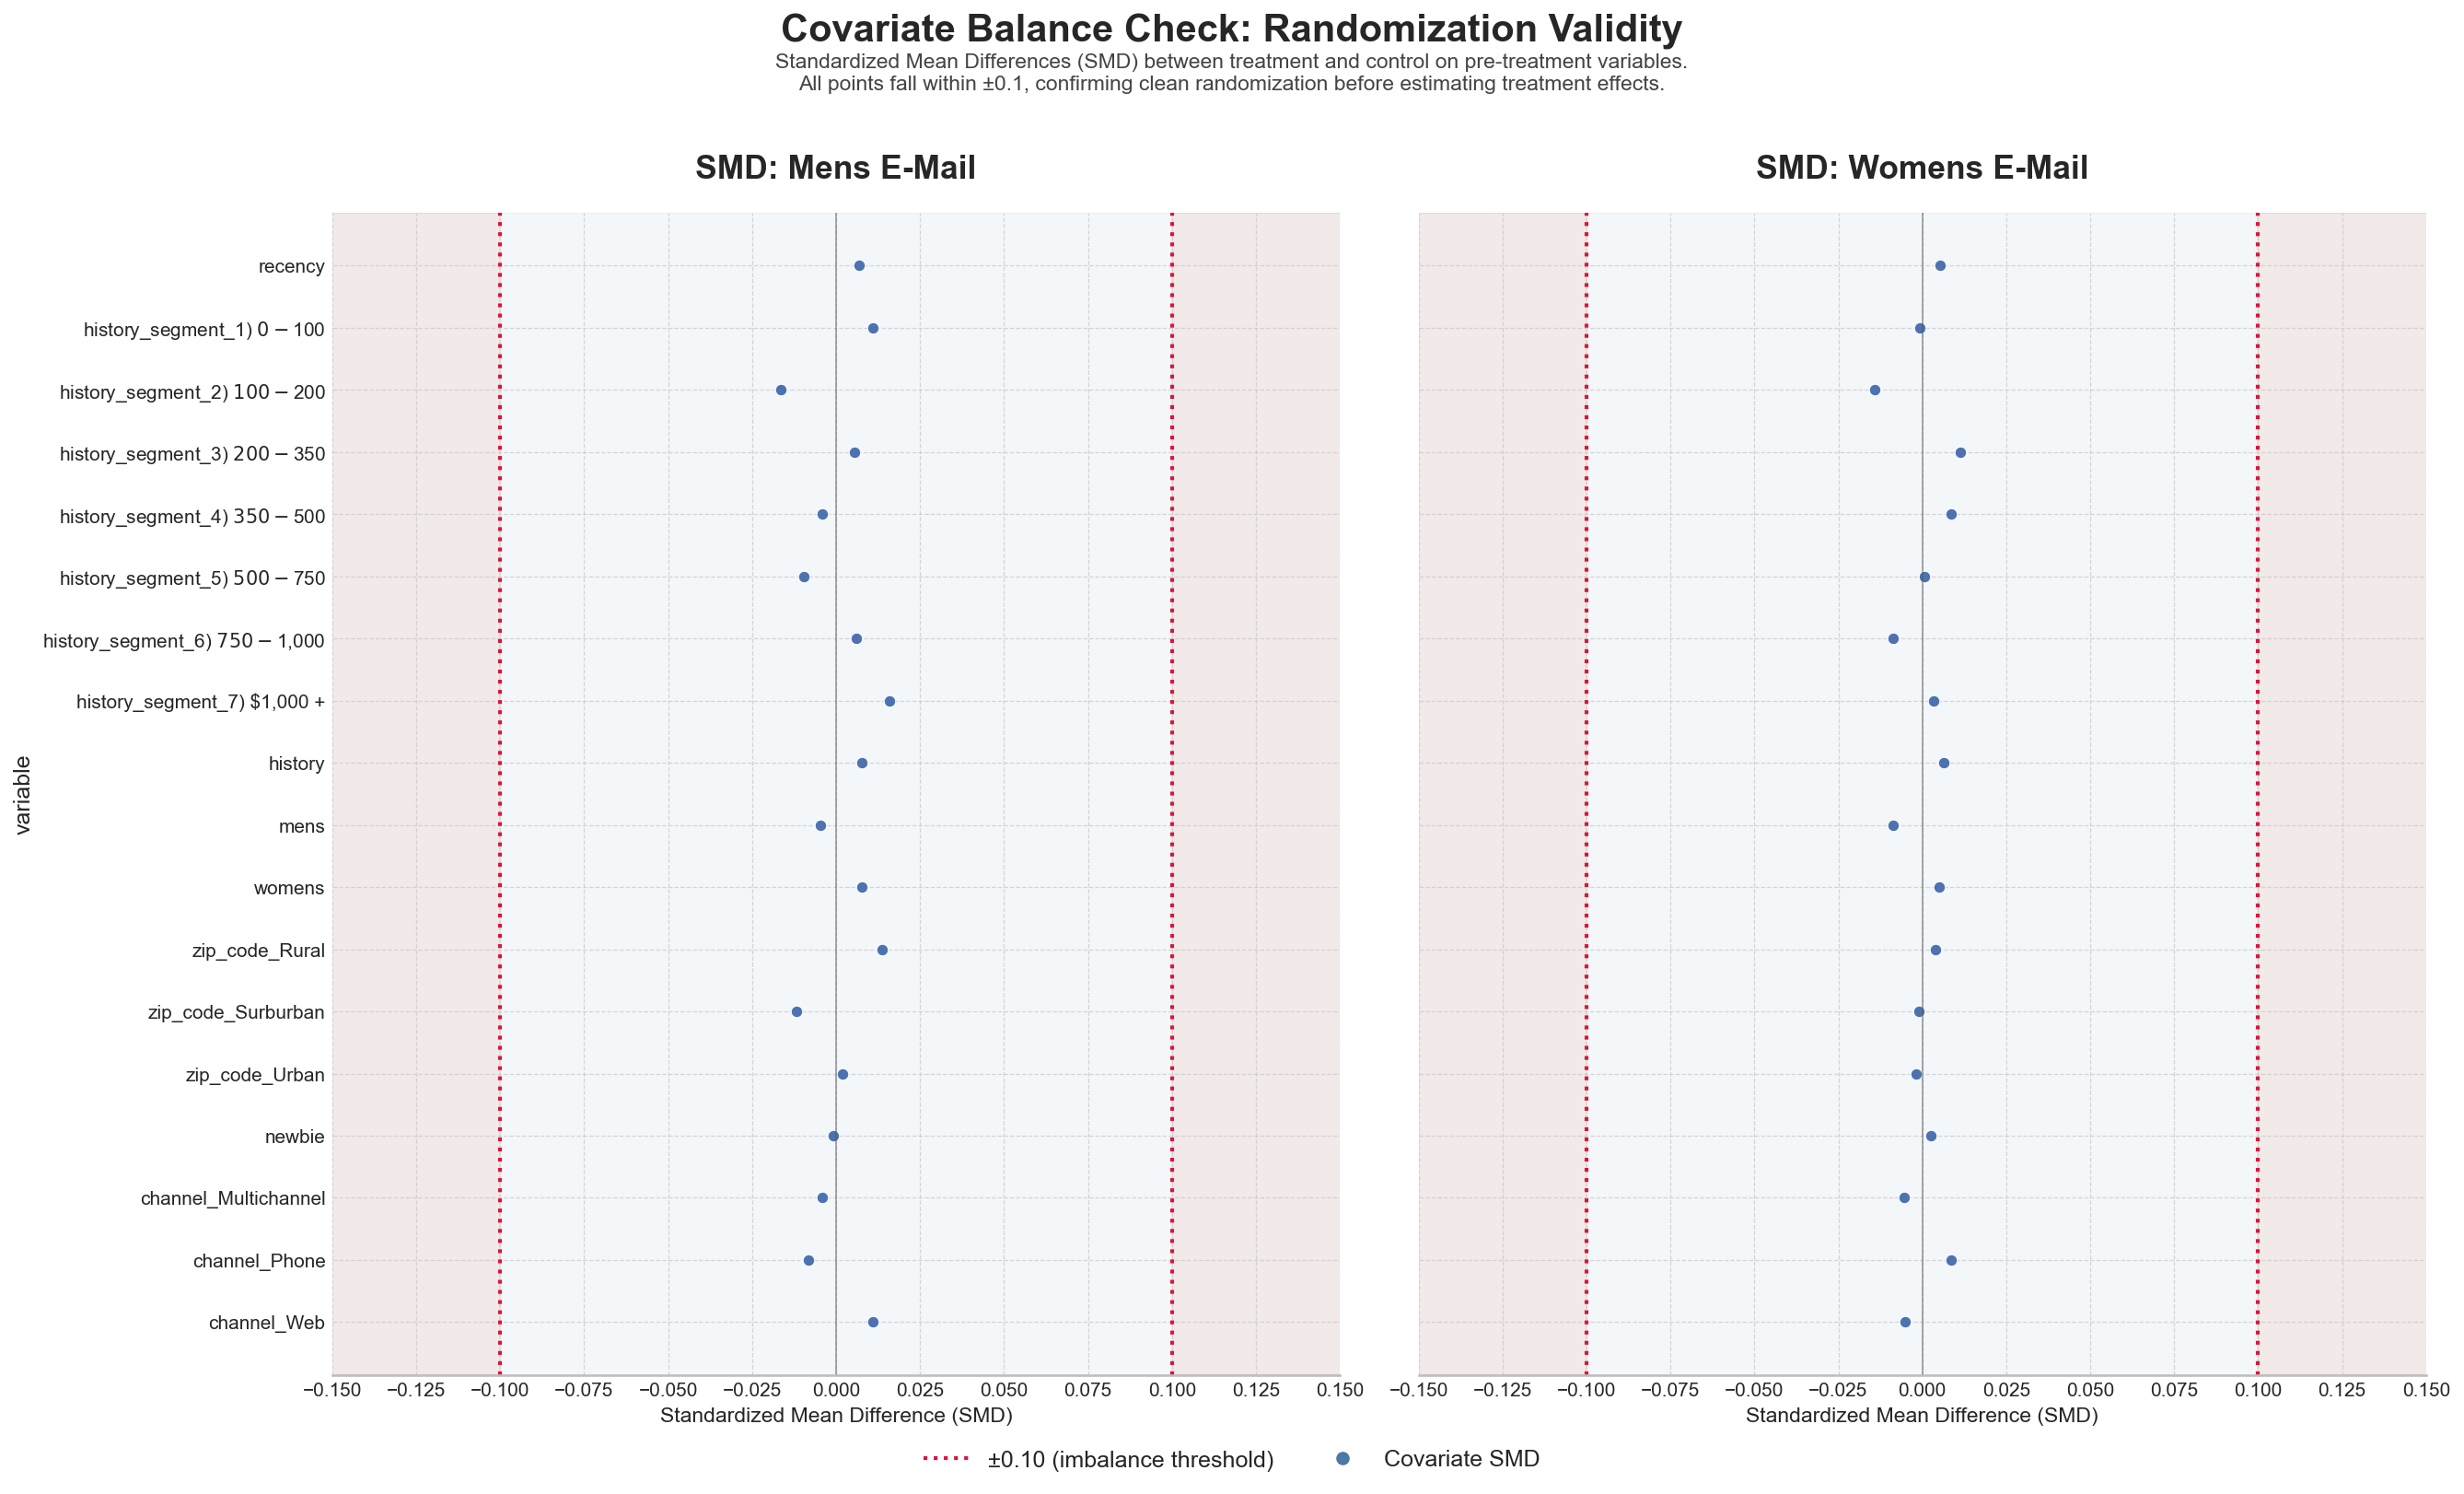

In [5]:
import numpy as np
precov = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code','newbie', 'channel']

def SMDM(df, treatment, covariates):
    results = []
    for variable in covariates:
        if pd.api.types.is_numeric_dtype(df[variable]):
            treated = df.loc[df[treatment]=="Mens E-Mail", variable]
            control = df.loc[df[treatment]=="No E-Mail", variable]

            SMD = (treated.mean() - control.mean())/np.sqrt((np.var(treated, ddof=1) + np.var(control, ddof=1))/2)
            results.append({"variable" : variable, "SMD" : SMD})
        else:
            dummies = pd.get_dummies(df[variable], prefix=variable)
            for category in dummies:
                treated = dummies.loc[df[treatment]=="Mens E-Mail", category]
                control = dummies.loc[df[treatment]=="No E-Mail", category]
                ptreat = treated.mean()
                pcontrol = control.mean()
                SMD = (ptreat-pcontrol)/np.sqrt(((ptreat * (1 - ptreat)) + (pcontrol * (1 - pcontrol)))/2)
                results.append({"variable" : category, "SMD" : SMD})        
    return pd.DataFrame(results)

def SMDF(df, treatment, covariates):
    results = []
    for variable in covariates:
        if pd.api.types.is_numeric_dtype(df[variable]):
            treated = df.loc[df[treatment]=="Womens E-Mail", variable]
            control = df.loc[df[treatment]=="No E-Mail", variable]

            SMD = (treated.mean() - control.mean())/np.sqrt((np.var(treated, ddof=1) + np.var(control, ddof=1))/2)
            results.append({"variable" : variable, "SMD" : SMD})
        else:
            dummies = pd.get_dummies(df[variable], prefix=variable)
            for category in dummies:
                treated = dummies.loc[df[treatment]=="Womens E-Mail", category]
                control = dummies.loc[df[treatment]=="No E-Mail", category]
                ptreat = treated.mean()
                pcontrol = control.mean()
                SMD = (ptreat-pcontrol)/np.sqrt(((ptreat * (1 - ptreat)) + (pcontrol * (1 - pcontrol)))/2)
                results.append({"variable" : category, "SMD" : SMD})        
    return pd.DataFrame(results)

balance_tableM = SMDM(df, "segment", precov)
balance_tableF = SMDF(df, "segment", precov)

print(balance_tableM)
print(balance_tableF)

#-------------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_theme(style="white")
fig, axes = plt.subplots(1,2, figsize=(18,10), dpi=150)
axes.flatten()
axes[0].axvspan(-0.25, 0.25, color="#4C78A8", alpha=0.06, zorder=0)
axes[1].axvspan(-0.25, 0.25, color="#4C78A8", alpha=0.06, zorder=0)
axes[0].axvspan(-1, -0.1, color="#E07A5F", alpha=0.1, zorder=0)
axes[0].axvspan(0.1, 1, color="#E07A5F", alpha=0.1, zorder=0)
axes[1].axvspan(-1, -0.1, color="#E07A5F", alpha=0.1, zorder=0)
axes[1].axvspan(0.1, 1, color="#E07A5F", alpha=0.1, zorder=0)
axes[0].axvline(0.1, color="crimson", linestyle=":", linewidth=2)
axes[0].axvline(-0.1, color="crimson", linestyle=":", linewidth=2)
axes[1].axvline(0.1, color="crimson", linestyle=":", linewidth=2)
axes[1].axvline(-0.1, color="crimson", linestyle=":", linewidth=2)

sns.scatterplot(balance_tableM, x="SMD", y="variable", ax=axes[0])
sns.scatterplot(balance_tableF, x="SMD", y="variable", ax=axes[1])

axes[0].grid(axis="both", linestyle="--", linewidth=0.6, alpha=0.8)
axes[1].grid(axis="both", linestyle="--", linewidth=0.6, alpha=0.8)

axes[0].spines["top"].set_visible(False) 
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_visible(False)

axes[1].spines["top"].set_visible(False) 
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

axes[0].spines["bottom"].set_color("#BEBEBE")
axes[1].spines["bottom"].set_color("#BEBEBE")

axes[0].tick_params(axis="both", length=0, labelsize=10) 
axes[1].tick_params(axis="both", length=0, labelsize=10)

axes[0].xaxis.set_major_locator(MultipleLocator(0.025))
axes[1].xaxis.set_major_locator(MultipleLocator(0.025))

axes[1].tick_params(axis="y", labelleft=False)
axes[1].set_ylabel("")

axes[0].set_title("SMD: Mens E-Mail",fontsize=17,weight="bold",pad=18)
axes[1].set_title("SMD: Womens E-Mail", fontsize=17, weight="bold", pad=18)

axes[0].set_xlim(-0.15, 0.15)
axes[1].set_xlim(-0.15, 0.15)

axes[0].axvline(0, color="#555555", linewidth=0.9, zorder=1, alpha=0.5)
axes[1].axvline(0, color="#555555", linewidth=0.9, zorder=1, alpha=0.5)

axes[0].set_xlabel("Standardized Mean Difference (SMD)", fontsize=11)
axes[1].set_xlabel("Standardized Mean Difference (SMD)", fontsize=11)

legend_elements = [
    Line2D([0], [0], color="crimson", linestyle=":", linewidth=2, label="±0.10 (imbalance threshold)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C78A8", markersize=8, label="Covariate SMD")
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Covariate Balance Check: Randomization Validity", fontsize=20, weight="bold", y=1.04)
fig.text(0.5, 0.985, "Standardized Mean Differences (SMD) between treatment and control on pre-treatment variables.\nAll points fall within ±0.1, confirming clean randomization before estimating treatment effects.",
         ha="center", fontsize=11, color="#444444")
plt.tight_layout()


## Step 4 — Outcome Exploration

count    64000.000000
mean         1.050908
std         15.036448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.000000
Name: spend, dtype: float64
Proportions of 0 spenders : 0.99096875


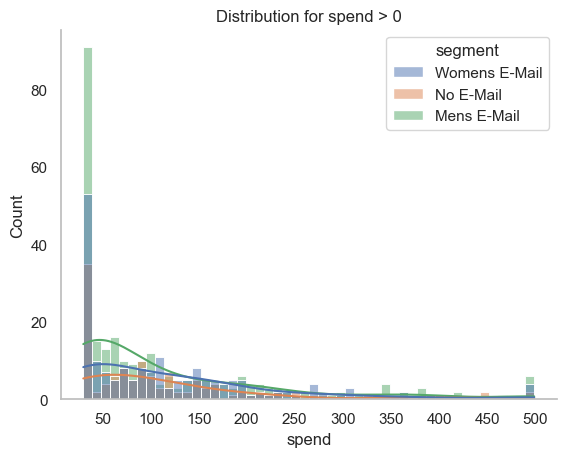

In [6]:
print(df['spend'].describe())
print(f"Proportions of 0 spenders : {(df['spend'] == 0).mean()}")
sns.set_theme(style='white')
sns.histplot(df[df['spend']>0], x='spend', hue='segment', bins=50, kde=True)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("#BEBEBE")
ax.spines['left'].set_color("#BEBEBE")
ax.set_title("Distribution for spend > 0")
ax.xaxis.set_major_locator(MultipleLocator(50))


In [7]:
from scipy.stats import skew
print(df.groupby('segment')[['visit', 'conversion']].mean())
print(f"skew fo spend > 0 : {skew(df[df['spend']>0]['spend'])}")


                  visit  conversion
segment                            
Mens E-Mail    0.182757    0.012531
No E-Mail      0.106167    0.005726
Womens E-Mail  0.151400    0.008837
skew fo spend > 0 : 1.7564047987622589


## Step 5 — Identification Assumptions

This  analysis relies on RCT identification strategy that require these assumptions to be true to hold
#### Unconfoundedness
Treatment assignment (segment) is independent from the outcome variables Y(1), Y(0) for both comparisons Mens Email and Womens Email vs No Email, this is by design as the treatment was assigned randomly not chosen by any customer characteristics. This is empirically supported by the results of SRM (sample ratio mismatch) showing no evidence of allocation mismatch (X² = 0.9) and with covariance balance check on all pre treatment variables with SMD (standardised mean difference) with no one of them over 0.1 for both arms

#### Positivity
Every customer had a non zero probability of receiving either treatment, this was assured by design assignment was fixed with 1/3,1/3,1/3 proportions for every treatment so each customer had a 1/3 chance of receiving each treatment and no subgroup was excluded from any treatment

#### SUTVA
No customer outcome is influenced by another's treatment though this is not 100% proven there is no evidence of a mechanism that create such influence none on the dataset and none on the documentation of the dataset on how it was assigned the emails were individually assigned and no evidence of otherwise

#### Consistency
Assignment of an Email corresponds to actual receipt of the Email there is no evidence of failure/confusion/mismatching on the process of email sent not on the dataset and not on the documentation though its plausible unless there is evidence its not true this assumption holds

#### No Differential Attrition by Arm
Data quality is consistent across all arms, no missing values, no inconsistencies and even duplications are proportional across all arms

## Step 6 — Estimator Selection & CUPED Implementation

In [13]:
from scipy import stats

subsetM = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
thetaM = subsetM['history'].cov(subsetM['spend'])/subsetM['history'].var()
subsetM['spend_cuped'] = subsetM['spend'] - thetaM * (subsetM['history'] - subsetM['history'].mean())

control_rawM = subsetM.loc[subsetM['segment'] == 'No E-Mail', 'spend']
treatment_rawM = subsetM.loc[subsetM['segment'] == 'Mens E-Mail', 'spend']
raw_resultM = stats.ttest_ind(treatment_rawM, control_rawM, equal_var=False)

control_cupedM = subsetM.loc[subsetM['segment'] == 'No E-Mail', 'spend_cuped']
treatment_cupedM = subsetM.loc[subsetM['segment'] == 'Mens E-Mail', 'spend_cuped']
treat_resultM = stats.ttest_ind(treatment_cupedM, control_cupedM, equal_var=False)

diff_raw_men = treatment_rawM.mean() - control_rawM.mean()

print(raw_resultM)
print(raw_resultM.confidence_interval(confidence_level=0.95))
print(treat_resultM)
print(treat_resultM.confidence_interval(confidence_level=0.95))


TtestResult(statistic=5.300140358411668, pvalue=1.1638149682254859e-07, df=36671.15797736051)
ConfidenceInterval(low=0.4851397325684075, high=1.0545145792206658)
TtestResult(statistic=5.284841624064931, pvalue=1.2653144672519646e-07, df=36676.63648675951)
ConfidenceInterval(low=0.4828128537957844, high=1.0520641450598198)


In [14]:
subsetF = df[df['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
thetaF = subsetF['history'].cov(subsetF['spend'])/subsetF['history'].var()
subsetF['spend_cuped'] = subsetF['spend'] - thetaF * (subsetF['history'] - subsetF['history'].mean())

control_rawF = subsetF.loc[subsetF['segment'] == 'No E-Mail', 'spend']
treatment_rawF = subsetF.loc[subsetF['segment'] == 'Womens E-Mail', 'spend']
raw_resultF = stats.ttest_ind(treatment_rawF, control_rawF, equal_var=False)

control_cupedF = subsetF.loc[subsetF['segment'] == 'No E-Mail', 'spend_cuped']
treatment_cupedF = subsetF.loc[subsetF['segment'] == 'Womens E-Mail', 'spend_cuped']
treat_resultF = stats.ttest_ind(treatment_cupedF, control_cupedF, equal_var=False)

diff_raw_women = treatment_rawF.mean() - control_rawF.mean()

print(raw_resultF)
print(raw_resultF.confidence_interval(confidence_level=0.95))
print(treat_resultF)
print(treat_resultF.confidence_interval(confidence_level=0.95))

TtestResult(statistic=3.2563715760253915, pvalue=0.0011293971023632519, df=40064.88440653066)
ConfidenceInterval(low=0.16895678988377866, high=0.6798676419894145)
TtestResult(statistic=3.243854656208933, pvalue=0.001180204734259644, df=40068.07875958844)
ConfidenceInterval(low=0.16729379164008584, high=0.6781080546729099)


### Key Visual — Does CUPED Actually Help Here?

CUPED reduces variance only in proportion to how strongly the pre-period covariate (`History`) correlates with the outcome (`Spend`). The plot below compares the raw and CUPED-adjusted estimates and 95% confidence intervals side by side, for both campaigns.


In [ ]:
import matplotlib.pyplot as plt

# Point estimates for the CUPED-adjusted comparisons
diff_cuped_men = treatment_cupedM.mean() - control_cupedM.mean()
diff_cuped_women = treatment_cupedF.mean() - control_cupedF.mean()

# Correlation driving CUPED's (lack of) variance reduction
corr_men = subsetM['history'].corr(subsetM['spend'])
corr_women = subsetF['history'].corr(subsetF['spend'])

rows = [
    ("Mens E-Mail",   "Raw",   diff_raw_men,     raw_resultM.confidence_interval(confidence_level=0.95)),
    ("Mens E-Mail",   "CUPED", diff_cuped_men,   treat_resultM.confidence_interval(confidence_level=0.95)),
    ("Womens E-Mail", "Raw",   diff_raw_women,   raw_resultF.confidence_interval(confidence_level=0.95)),
    ("Womens E-Mail", "CUPED", diff_cuped_women, treat_resultF.confidence_interval(confidence_level=0.95)),
]

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

colors = {"Raw": "#4C78A8", "CUPED": "#E07A5F"}
y_positions = [3, 2, 1, 0]

for y, (segment, method, point, ci) in zip(y_positions, rows):
    lower_err = point - ci.low
    upper_err = ci.high - point
    ax.errorbar(point, y, xerr=[[lower_err], [upper_err]], fmt='o',
                color=colors[method], capsize=6, markersize=9,
                linewidth=2.2, elinewidth=2.2)

ax.axvline(0, color="#999999", linewidth=1, linestyle="--")

ax.set_yticks(y_positions)
ax.set_yticklabels([f"{seg}\n{meth}" for seg, meth, _, _ in rows], fontsize=11)

ax.set_xlabel("Estimated effect on Spend ($)", fontsize=11)
ax.set_title("CUPED barely moves the estimate:\nraw and adjusted intervals nearly overlap",
             fontsize=14, weight="bold", pad=16)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[m],
                       markersize=9, label=m) for m in ["Raw", "CUPED"]]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=10)

ax.text(0.98, 0.02,
        f"History–Spend correlation:\nMens r = {corr_men:.3f}   |   Womens r = {corr_women:.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="#555555")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


## Step 7 — Robustness Checks

In [15]:
from scipy.stats import mannwhitneyu

mw_mens = mannwhitneyu(treatment_rawM, control_rawM, alternative='two-sided')
print(mw_mens)

mw_womens = mannwhitneyu(treatment_rawF, control_rawF, alternative='two-sided')
print(mw_womens)

# both Mens and Womens reject H0 (no systemic difference between treatment and control) and validate ttest results more

MannwhitneyuResult(statistic=228527081.0, pvalue=1.5819988266809648e-13)
MannwhitneyuResult(statistic=228545030.0, pvalue=0.00015545166680000966)


In [16]:
nonzero_spend = subsetM.loc[subsetM['spend'] > 0, 'spend']
cap = nonzero_spend.quantile(0.95)  
subsetM['spend_capped'] = subsetM['spend'].clip(upper=cap)

treat_capped = subsetM.loc[subsetM['segment']=="Mens E-Mail", 'spend_capped']
control_capped = subsetM.loc[subsetM['segment']=="No E-Mail", 'spend_capped']
capped_result = stats.ttest_ind(treat_capped, control_capped, equal_var=False)
print(capped_result)
print(capped_result.confidence_interval(confidence_level=0.95))

nonzero_spend = subsetF.loc[subsetF['spend'] > 0, 'spend']
cap = nonzero_spend.quantile(0.95)
subsetF['spend_capped'] =  subsetF['spend'].clip(upper=cap)
treat_capped = subsetF.loc[subsetF['segment']=="Womens E-Mail", 'spend_capped']
control_capped = subsetF.loc[subsetF['segment']=="No E-Mail", 'spend_capped']
capped_result = stats.ttest_ind(treat_capped, control_capped, equal_var=False)
print(capped_result)
print(capped_result.confidence_interval(confidence_level=0.95))

TtestResult(statistic=5.473103571249588, pvalue=4.451086002939942e-08, df=36723.403193571496)
ConfidenceInterval(low=0.4759810601374813, high=1.0071035026851565)
TtestResult(statistic=3.4114901781549096, pvalue=0.0006467291824278839, df=39869.64360287399)
ConfidenceInterval(low=0.17584808798729876, high=0.6507696066154582)


## Step 8 — Final Estimates & Business Translation

In [ ]:
print("Mens: ", diff_raw_men, raw_resultM.confidence_interval(confidence_level=0.95))
print("Womens: ", diff_raw_women, raw_resultF.confidence_interval(confidence_level=0.95))

Mens:  0.7698271558945367 ConfidenceInterval(low=0.4851397325684075, high=1.0545145792206658)
Womens:  0.4244122159365966 ConfidenceInterval(low=0.16895678988377866, high=0.6798676419894145)


Two independent hypothesis tests were conducted against a shared control group: Mens E-Mail vs. No E-Mail, and Womens E-Mail vs. No E-Mail, on Spend. Applying a Bonferroni correction for two comparisons (adjusted significance threshold: α = 0.025), both effects remain statistically significant. The Mens E-Mail effect (p = 1.16 × 10⁻⁷) and the Womens E-Mail effect (p = 0.0011) both comfortably clear the corrected threshold, supporting a joint conclusion that both campaigns produced a genuine increase in customer spend, not attributable to chance or to running multiple tests against the same baseline.

In [18]:
# total added conversions for men
rate_mens = subsetM.loc[subsetM['segment']=="Mens E-Mail", 'conversion'].mean()
rate_control_mens = subsetM.loc[subsetM['segment']=="No E-Mail", 'conversion'].mean()
n_mens = (subsetM['segment']=="Mens E-Mail").sum()
incremental_conversions_mens = (rate_mens - rate_control_mens) * n_mens
print(incremental_conversions_mens)

# total added conversions for women
rate_womens = subsetF.loc[subsetF['segment']=="Womens E-Mail", 'conversion'].mean()
rate_control_womens = subsetF.loc[subsetF['segment']=="No E-Mail", 'conversion'].mean()
n_womens = (subsetF['segment']=="Womens E-Mail").sum()
incremental_conversions_womens = (rate_womens - rate_control_womens) * n_womens
print(incremental_conversions_womens)

144.99427391345162
66.53618698958041


Sending the Mens E-Mail campaign to the full eligible customer base is estimated to generate approximately 145 and an average incremental spend of $0.76 per customer (95% CI: (low=0.485, high=1.055)), scaled across the ~21,300 customers in this arm. The Womens E-Mail campaign, while a smaller effect, still produced approximately 67 and $0.4 average incremental spend per customer (95% CI: (low=0.168, high=0.679)). Given email's low marginal cost per send, both campaigns appear to have generated positive incremental revenue well in excess of their delivery cost, though exact ROI would require the retailer's actual cost-per-send and margin figures, which are not available in this dataset.

## Step 9 — Heterogeneous Treatment Effects (Uplift Modeling)

Individual-level CATE estimates for Conversion via an X-learner. As a sanity check, the mean of the individual CATE predictions should reconstruct the population-level ATE from Step 8.

In [ ]:
from econml.metalearners import XLearner
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

X_learner = XLearner(
    models=GradientBoostingRegressor(),
    propensity_model=LogisticRegression(),
    cate_models=GradientBoostingRegressor()
)

data = subsetM.copy() 
data['treatment_flag'] = (data['segment'] == 'Mens E-Mail').astype(int)
X_cols = ['recency', 'history', 'mens', 'womens', 'newbie']
categorical_cols = ['zip_code', 'channel'] 
X_encoded = pd.get_dummies(data[X_cols + categorical_cols], columns=categorical_cols, drop_first=True)

X_learner.fit(Y=data['conversion'], T=data['treatment_flag'], X=X_encoded)
cate_estimates = X_learner.effect(X_encoded)
data['cate_conversion'] = cate_estimates

print(data['cate_conversion'].describe())
print(data['cate_conversion'].quantile([0.01, 0.05, 0.95, 0.99]))

count    42613.000000
mean         0.006688
std          0.011433
min         -0.445223
25%          0.004009
50%          0.006011
75%          0.008627
max          0.404775
Name: cate_conversion, dtype: float64
0.01   -0.000045
0.05    0.001770
0.95    0.014160
0.99    0.022366
Name: cate_conversion, dtype: float64


c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [43]:
from econml.metalearners import XLearner
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

X_learner = XLearner(
    models=GradientBoostingRegressor(),
    propensity_model=LogisticRegression(),
    cate_models=GradientBoostingRegressor()
)

data = subsetF.copy()  
data['treatment_flag'] = (data['segment'] == 'Womens E-Mail').astype(int)
X_cols = ['recency', 'history', 'mens', 'womens', 'newbie']
categorical_cols = ['zip_code', 'channel']  
X_encoded = pd.get_dummies(data[X_cols + categorical_cols], columns=categorical_cols, drop_first=True)

X_learner.fit(Y=data['conversion'], T=data['treatment_flag'], X=X_encoded)
cate_estimates = X_learner.effect(X_encoded)
data['cate_conversion'] = cate_estimates

print(data['cate_conversion'].describe())
print(data['cate_conversion'].quantile([0.01, 0.05, 0.95, 0.99]))

count    42693.000000
mean         0.003266
std          0.014133
min         -0.677845
25%          0.000212
50%          0.003102
75%          0.005582
max          0.405210
Name: cate_conversion, dtype: float64
0.01   -0.007927
0.05   -0.004321
0.95    0.010885
0.99    0.017663
Name: cate_conversion, dtype: float64


c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Scope Note

The mean of the individual CATE estimates closely reconstructs the population ATE for both campaigns, a good internal consistency check on the model. Deeper subgroup claims (e.g., targeting rules derived from the tails of the CATE distribution) require out-of-sample validation before being trusted or used operationally, and are left as future work rather than reported here.